# Instance-Based Learning
## A Detailed Guide: k-Nearest Neighbours & Locally Weighted Regression

**References:**
- Tom Mitchell, *Machine Learning*, Chapter 8 — Instance-Based Learning
- Lecture 13 notes (CS456 — NISER, Spring 2023)
- Peter Harrington, *Machine Learning in Action*, Chapter 2

**Datasets:** Iris · Wine · Digits (scikit-learn)

---

This notebook is structured in two major parts:

| Part | Model | Module |
|------|-------|--------|
| **Part I** | k-Nearest Neighbours (k-NN) | `knn_applications.py` |
| **Part II** | Locally Weighted Regression (LWR) | `weighted_regression.py` |

Each part contains **Theory** (concepts, formulations, pros/cons) followed by **Applications** on three real datasets.

---
# PART I — k-Nearest Neighbours (k-NN)
---

## 1. Theory

### 1.1 Instance-Based (Lazy) Learning

Instance-based learning methods defer all generalisation until a new query is received (Mitchell Ch.8).  
Instead of building a global model during training, the learner simply **stores** all training examples and constructs a **local approximation** only when needed.

Advantages:
- Can represent extremely complex target functions (different hypothesis per query).
- No information is thrown away during training.

Disadvantages:
- Classification is expensive — must scan all stored examples.
- High memory usage.
- Susceptible to the **curse of dimensionality**.

### 1.2 k-NN Algorithm

Given a query $x_q$ and training set $D = \{(x_i, y_i)\}$:

1. Compute distance $d(x_q, x_i)$ for every stored example.
2. Sort distances in ascending order.
3. Select the $k$ nearest neighbours $N_k(x_q)$.
4. **Classification:** return the majority class   $\hat{y} = \arg\max_v \sum_{(x_i,y_i) \in N_k} \delta(v, y_i)$
5. **Regression:** return the mean  $\hat{f}(x_q) = \frac{1}{k} \sum_{(x_i,y_i) \in N_k} y_i$

### 1.3 Distance Metrics

| Metric | Formula | Notes |
|--------|---------|-------|
| **Euclidean** (L₂) | $d = \sqrt{\sum_i (x_i - y_i)^2}$ | Default; sensitive to scaling |
| **Manhattan** (L₁) | $d = \sum_i |x_i - y_i|$ | More robust in high-d |
| **Minkowski** (Lₚ) | $d = \left(\sum_i |x_i - y_i|^p\right)^{1/p}$ | Generalises L₁ and L₂ |
| **Chebyshev** (L∞) | $d = \max_i |x_i - y_i|$ | Only largest difference matters |

### 1.4 Effect of k

| k | Bias | Variance | Boundary | Risk |
|---|------|----------|----------|------|
| 1 | Low | High | Jagged (Voronoi) | Overfitting |
| 3–5 | ↑ | ↓ | Complex but smoother | Slight overfitting |
| 7–15 | Medium | Medium | **Best generalisation** | — |
| ≫√n | High | Low | Nearly linear | Underfitting |

**Rule of thumb:** $k \approx \sqrt{n}$, then cross-validate.

### 1.5 Distance-Weighted k-NN

Rather than treating all $k$ neighbours equally, weight each by the inverse square of its distance (Mitchell §8.2.1):

$$w_i = \frac{1}{d(x_q, x_i)^2}$$

$$\hat{y} = \arg\max_v \sum_{(x_i,y_i) \in N_k} w_i \cdot \delta(v, y_i)$$

Benefits: reduces sensitivity to the choice of $k$; even with $k = n$, only nearby points contribute.

### 1.6 Curse of Dimensionality

In high-dimensional spaces:
- Distances **concentrate** — all points appear equally far.
- Data needed grows **exponentially** with dimensionality.
- Irrelevant features add noise to distance → degraded performance.

Mitigations: PCA, feature selection, feature weighting, use Manhattan distance.

## 2. Theory Display (detailed terminal printout)

In [1]:
!git clone https://github.com/niceGriffith/Learning_ML

Cloning into 'Learning_ML'...
remote: Enumerating objects: 19, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 19 (delta 1), reused 19 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (19/19), 3.69 MiB | 25.70 MiB/s, done.
Resolving deltas: 100% (1/1), done.


In [3]:
%cd Learning_ML/Machine\ Learning

/content/Learning_ML/Machine Learning


In [4]:
import knn_applications

# Display all k-NN theory sections
knn_applications.display_all_theory()


  1. INSTANCE-BASED LEARNING — INTRODUCTION

Instance-based learning (also called *lazy learning* or *memory-based
learning*) defers generalisation until a new query is received.

Key idea (Mitchell Ch.8):
  ● Instead of building an explicit model during training, the learner
    simply STORES all training examples.
  ● When a new query instance x_q arrives, the stored examples are used
    to construct a LOCAL approximation to the target function.
  ● Only the region of the instance space surrounding x_q is examined.

Why "lazy"?
  ● No computation is performed at training time.
  ● All computation is deferred to classification / prediction time.
  ● Contrast with "eager" learners (decision trees, neural nets, SVMs)
    that build a global model before seeing any query.

Advantages of lazy learning:
  ✓ The hypothesis can be different for every query → can represent
    very complex (even discontinuous) target functions.
  ✓ No information is discarded during training.

Disadvantages

## 3. Application — Dataset 1: Iris

The **Iris** dataset (150 samples, 4 features, 3 classes) is the classic ML benchmark.  
We analyse: accuracy vs $k$, distance metric comparison, uniform vs weighted, and decision boundaries.


  DATASET DEMO — IRIS

────────────────────────────────────────────────────────────
  Dataset : Iris
  Samples : 150
  Features: 4
  Classes : 3  →  [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
────────────────────────────────────────────────────────────

▶ 3a. Accuracy vs k (Euclidean, uniform weighting):
    k= 1  →  accuracy = 0.9474
    k= 3  →  accuracy = 0.9211
    k= 5  →  accuracy = 0.9211
    k= 7  →  accuracy = 0.9474
    k= 9  →  accuracy = 0.9737
    k=11  →  accuracy = 0.9737
    k=15  →  accuracy = 0.9737
    k=21  →  accuracy = 0.9211


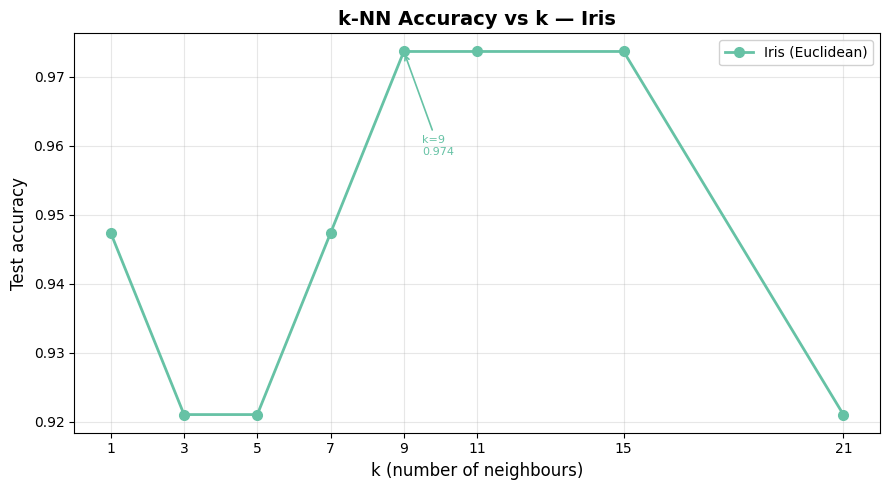


▶ 3b. Distance metric comparison:
    Euclidean          best: k= 9  acc=0.9737
    Manhattan          best: k= 9  acc=0.9737
    Minkowski (p=3)    best: k= 9  acc=0.9737
    Chebyshev          best: k=11  acc=0.9474


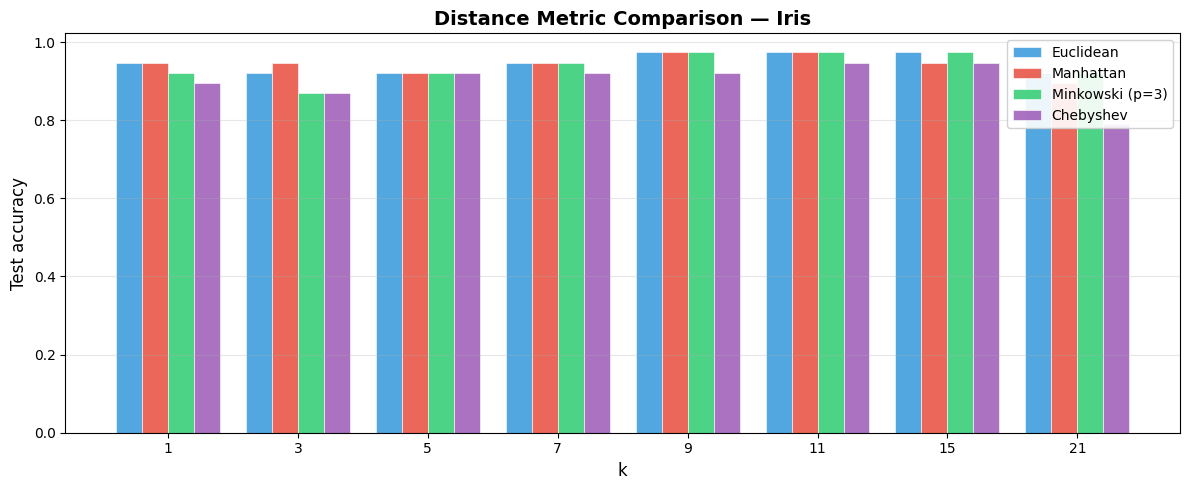


▶ 3c. Uniform vs Distance-weighted:
    Uniform              best: k= 9  acc=0.9737
    Distance-weighted    best: k= 7  acc=0.9737


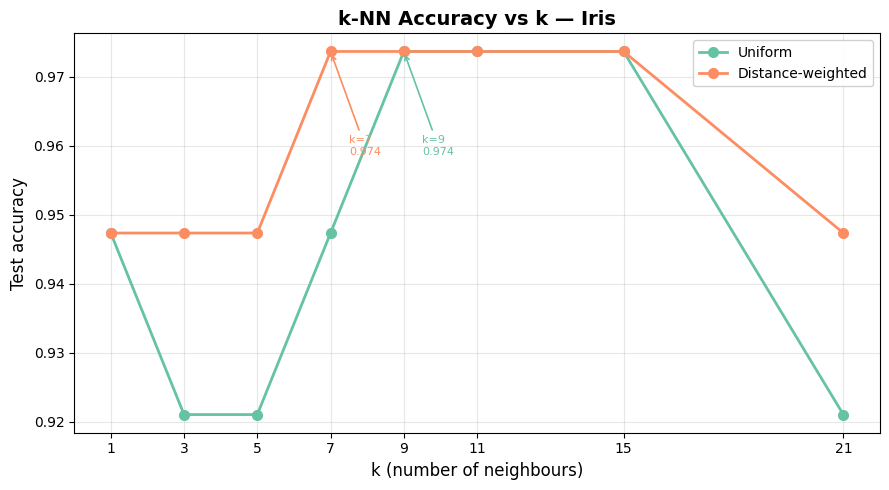


▶ 3d. Confusion matrix at best k=9:


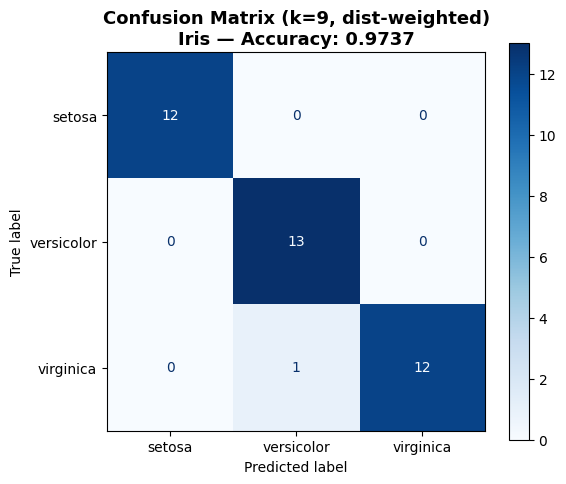


  Classification Report  (k=9, Iris):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.93      1.00      0.96        13
   virginica       1.00      0.92      0.96        13

    accuracy                           0.97        38
   macro avg       0.98      0.97      0.97        38
weighted avg       0.98      0.97      0.97        38



In [5]:
from sklearn.datasets import load_iris
knn_applications.demo_dataset(load_iris, "Iris")

### 3.1 Decision Boundary Visualisation (Iris, 2D)

Below we plot k-NN decision boundaries for $k = 1, 3, 7, 15$ using petal length and petal width.  
Notice how the boundary smooths out as $k$ increases.

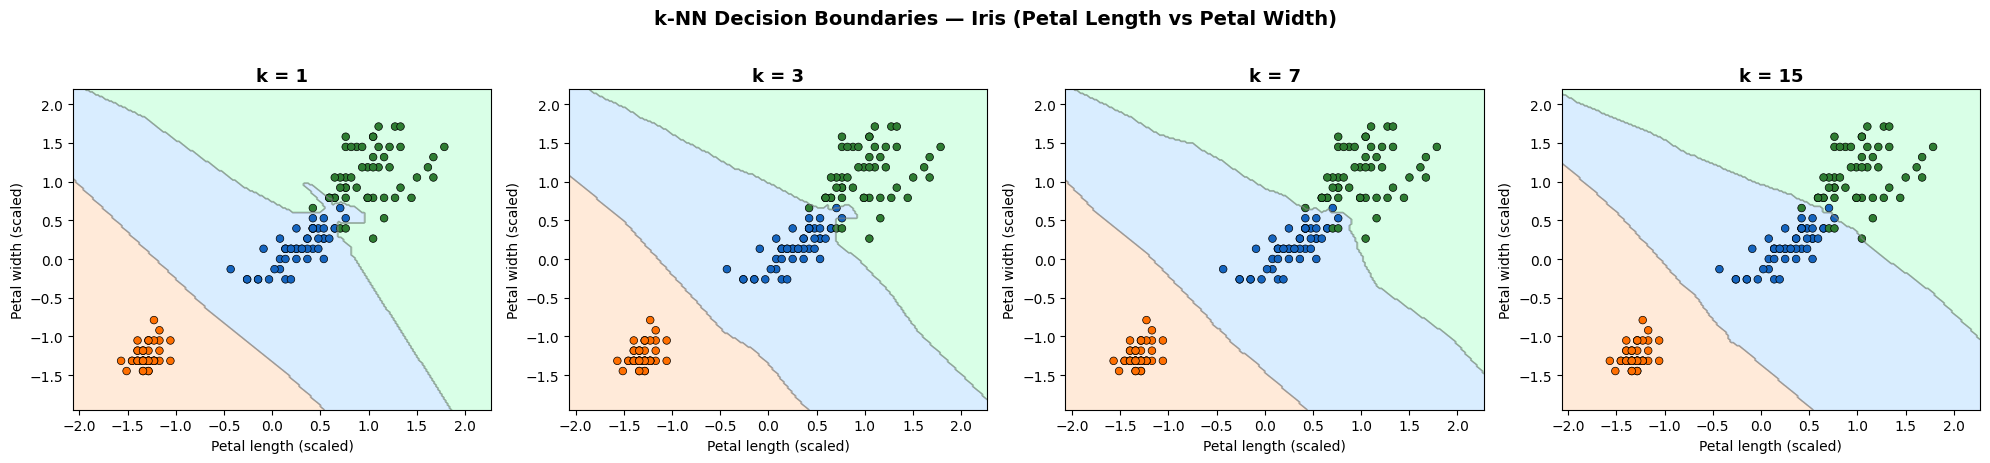


  Observation:
  ● k=1 produces very complex, jagged boundaries that overfit noise.
  ● k=3 smooths out small anomalies; still captures local structure.
  ● k=7 gives a cleaner boundary with good generalisation.
  ● k=15 is very smooth — starts to under-fit subtle patterns.



In [6]:
knn_applications.plot_decision_boundaries_iris()

## 4. Application — Dataset 2: Wine

The **Wine** dataset (178 samples, 13 features, 3 classes) tests k-NN in a higher-dimensional setting.  
Feature scaling is critical here because features have very different ranges.


  DATASET DEMO — WINE

────────────────────────────────────────────────────────────
  Dataset : Wine
  Samples : 178
  Features: 13
  Classes : 3  →  [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]
────────────────────────────────────────────────────────────

▶ 3a. Accuracy vs k (Euclidean, uniform weighting):
    k= 1  →  accuracy = 0.9556
    k= 3  →  accuracy = 0.9556
    k= 5  →  accuracy = 0.9333
    k= 7  →  accuracy = 0.9778
    k= 9  →  accuracy = 0.9778
    k=11  →  accuracy = 0.9778
    k=15  →  accuracy = 1.0000
    k=21  →  accuracy = 1.0000


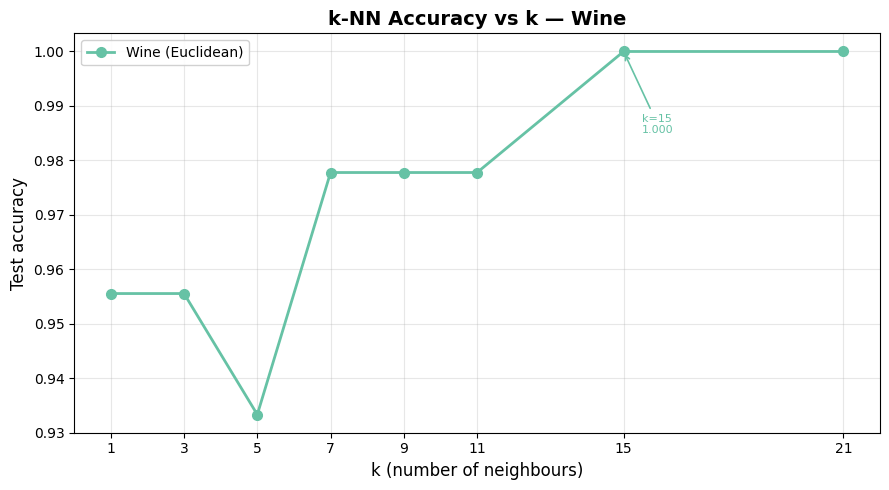


▶ 3b. Distance metric comparison:
    Euclidean          best: k=15  acc=1.0000
    Manhattan          best: k= 5  acc=0.9778
    Minkowski (p=3)    best: k=21  acc=1.0000
    Chebyshev          best: k=21  acc=0.9556


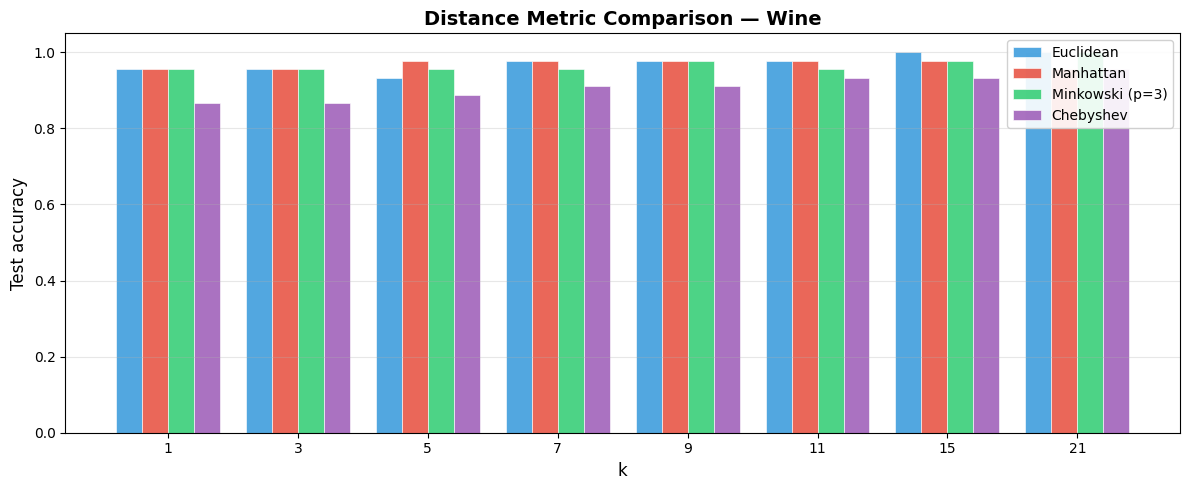


▶ 3c. Uniform vs Distance-weighted:
    Uniform              best: k=15  acc=1.0000
    Distance-weighted    best: k=15  acc=1.0000


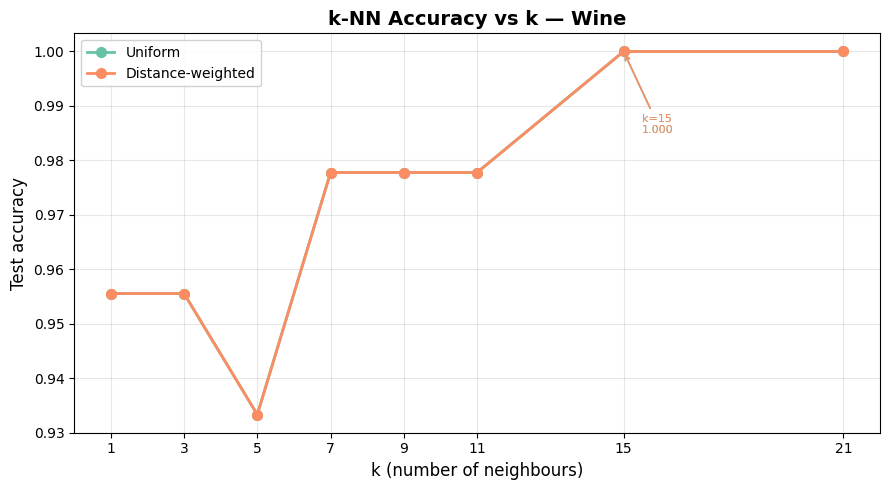


▶ 3d. Confusion matrix at best k=15:


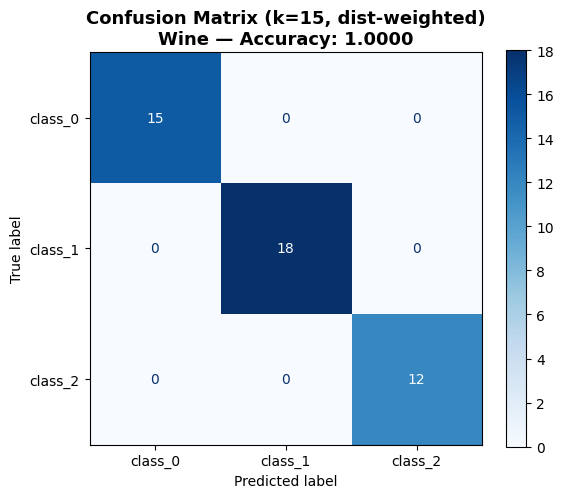


  Classification Report  (k=15, Wine):
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        15
     class_1       1.00      1.00      1.00        18
     class_2       1.00      1.00      1.00        12

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [7]:
from sklearn.datasets import load_wine
knn_applications.demo_dataset(load_wine, "Wine")

## 5. Application — Dataset 3: Digits

The **Digits** dataset (1797 samples, 64 features = 8×8 pixel images, 10 classes) mirrors the handwriting recognition problem from Lecture 13.  
This is the most challenging dataset: high-dimensional, 10-class classification.


  DATASET DEMO — DIGITS

────────────────────────────────────────────────────────────
  Dataset : Digits
  Samples : 1797
  Features: 64
  Classes : 10  →  [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
────────────────────────────────────────────────────────────

▶ 3a. Accuracy vs k (Euclidean, uniform weighting):
    k= 1  →  accuracy = 0.9711
    k= 3  →  accuracy = 0.9667
    k= 5  →  accuracy = 0.9644
    k= 7  →  accuracy = 0.9644
    k= 9  →  accuracy = 0.9644
    k=11  →  accuracy = 0.9578
    k=15  →  accuracy = 0.9489
    k=21  →  accuracy = 0.9400


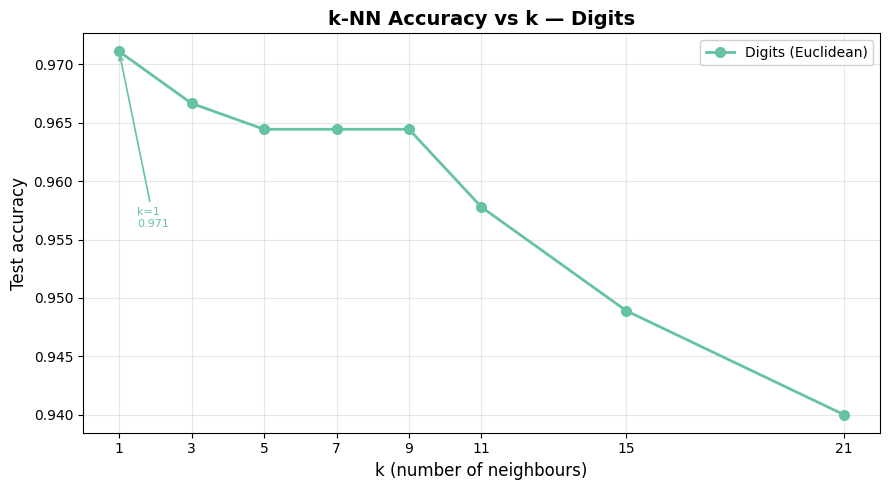


▶ 3b. Distance metric comparison:
    Euclidean          best: k= 1  acc=0.9711
    Manhattan          best: k= 5  acc=0.9800
    Minkowski (p=3)    best: k= 7  acc=0.9644
    Chebyshev          best: k= 3  acc=0.9378


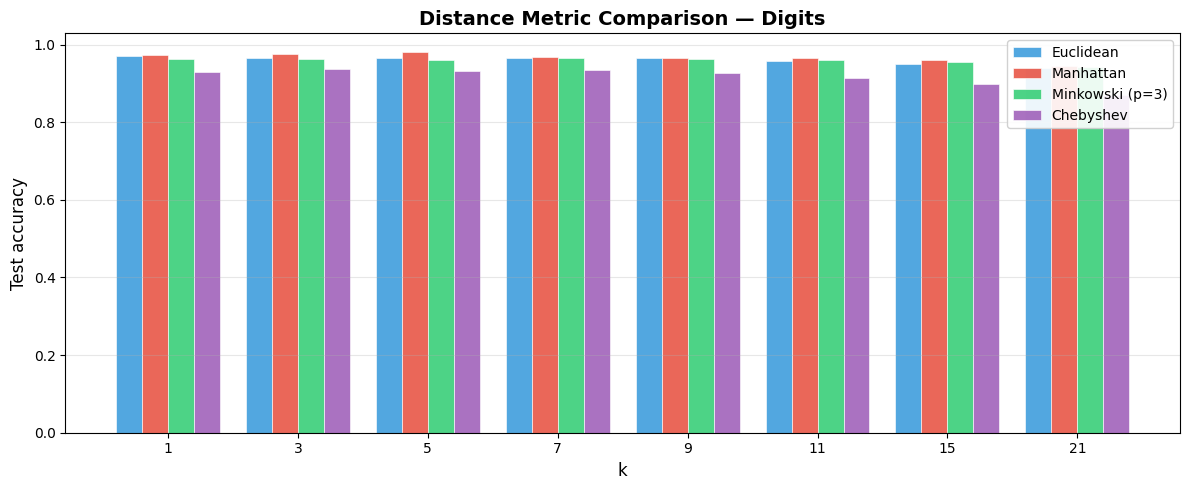


▶ 3c. Uniform vs Distance-weighted:
    Uniform              best: k= 1  acc=0.9711
    Distance-weighted    best: k= 1  acc=0.9711


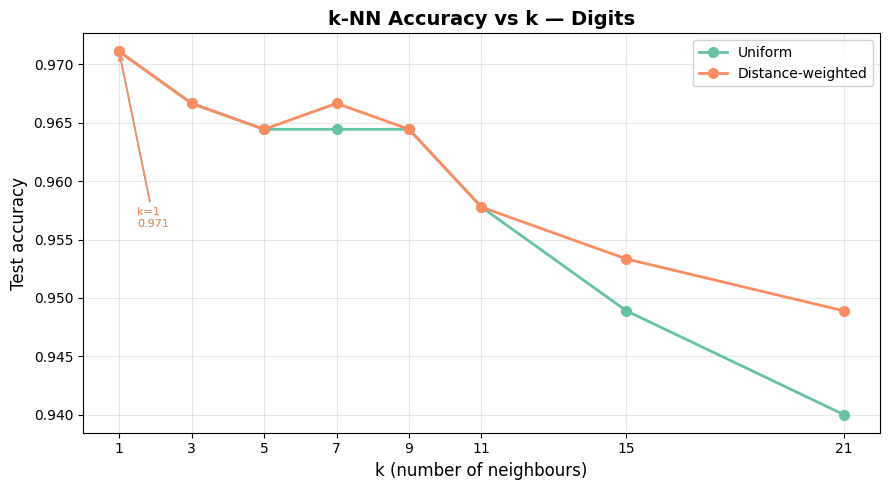


▶ 3d. Confusion matrix at best k=1:


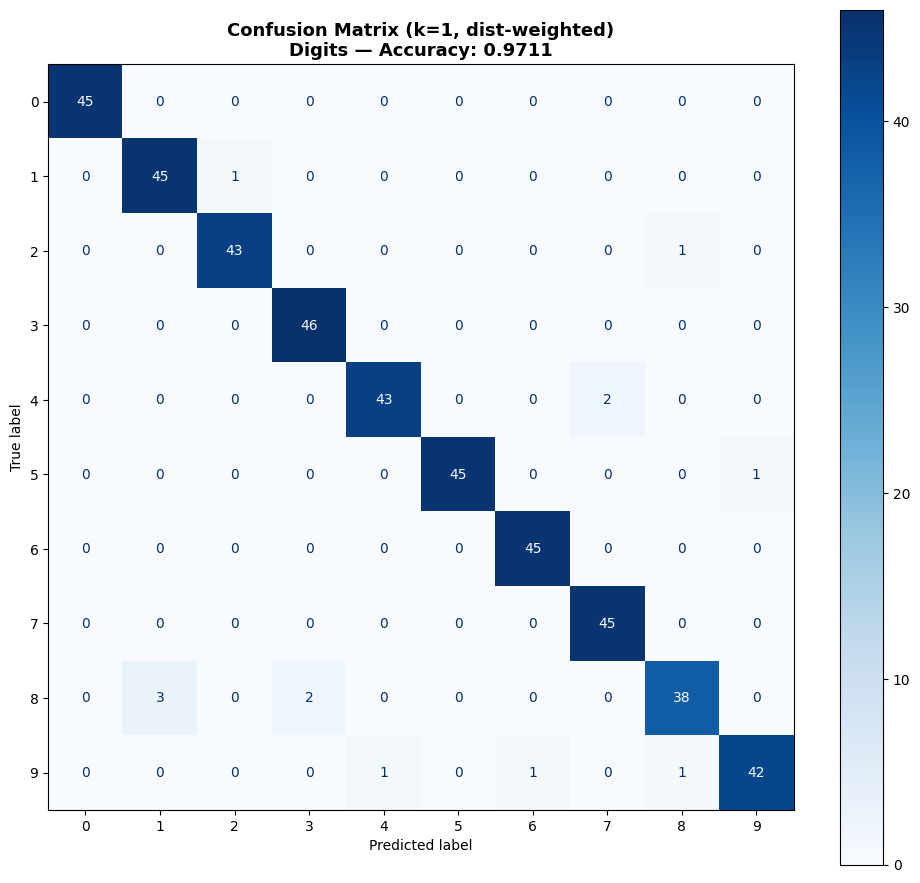


  Classification Report  (k=1, Digits):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        45
           1       0.94      0.98      0.96        46
           2       0.98      0.98      0.98        44
           3       0.96      1.00      0.98        46
           4       0.98      0.96      0.97        45
           5       1.00      0.98      0.99        46
           6       0.98      1.00      0.99        45
           7       0.96      1.00      0.98        45
           8       0.95      0.88      0.92        43
           9       0.98      0.93      0.95        45

    accuracy                           0.97       450
   macro avg       0.97      0.97      0.97       450
weighted avg       0.97      0.97      0.97       450



In [8]:
from sklearn.datasets import load_digits
knn_applications.demo_dataset(load_digits, "Digits")

---
# PART II — Locally Weighted Regression (LWR)
---

## 6. Theory

### 6.1 What is Locally Weighted Regression?

LWR (Mitchell Ch.8 §8.3) generalises k-NN regression by fitting a **local linear model** around each query point $x_q$, rather than just averaging neighbour values.

**Key steps:**
1. Assign a weight to each training example: $w_i = \exp\left(-\frac{\|x_q - x_i\|^2}{2\tau^2}\right)$  (Gaussian kernel)
2. Solve weighted least squares: $\theta^* = (X^T W X)^{-1} X^T W y$
3. Predict: $\hat{y}_q = \theta^{*T} x_q$

### 6.2 Bandwidth Parameter τ

| τ | Effect |
|---|--------|
| Very small (0.01–0.1) | Only closest points matter → overfits, wiggly |
| Medium (0.5–2.0) | Good balance — captures trends, smooths noise |
| Very large (10+) | All points weighted equally → global linear regression |

τ is analogous to $k$ in k-NN: controls the bias-variance trade-off.

### 6.3 LWR vs k-NN Regression

| Aspect | k-NN Regression | LWR |
|--------|----------------|-----|
| Local model | None (just mean) | Linear / polynomial |
| Smoothness | Piecewise constant | Piecewise linear |
| Hyper-param | k | τ |
| Fit quality | Step-like | Smooth curve |
| Cost/query | O(n) | O(n·d²) |

## 7. Theory Display (detailed terminal printout)

In [9]:
import weighted_regression

# Display all LWR theory sections
weighted_regression.display_all_theory()


  1. LOCALLY WEIGHTED REGRESSION — OVERVIEW

Locally Weighted Regression (LWR) is an instance-based method for
approximating REAL-VALUED target functions (Mitchell Ch.8 §8.3).

Key difference from k-NN regression:
  ● k-NN regression:  f̂(x_q) = mean of k nearest neighbours' targets.
  ● LWR:  fits a LOCAL function (e.g. a line or quadratic surface)
    to the neighbourhood around x_q, weighted by distance.

Why "locally weighted"?
  ● "Local"    → only nearby training examples matter.
  ● "Weighted" → closer examples have MORE influence on the fit.
  ● A separate fit is constructed for EACH query — no single global
    model is ever stored.

Contrast with standard (global) linear regression:
  ● Standard LR finds ONE set of coefficients θ that minimises the
    error across ALL training examples.
  ● LWR finds a DIFFERENT set of coefficients for every query x_q,
    emphasising training examples near x_q.

This makes LWR an INSTANCE-BASED (lazy) learner: no training phase,
all work i

## 8. Application — Demo 1: 1D Synthetic Data

A 1D non-linear function with noise is the best setting to **visualise** the effect of τ.  
We also compare LWR against k-NN regression and global linear regression.


  DEMO 1 — 1D SYNTHETIC DATA


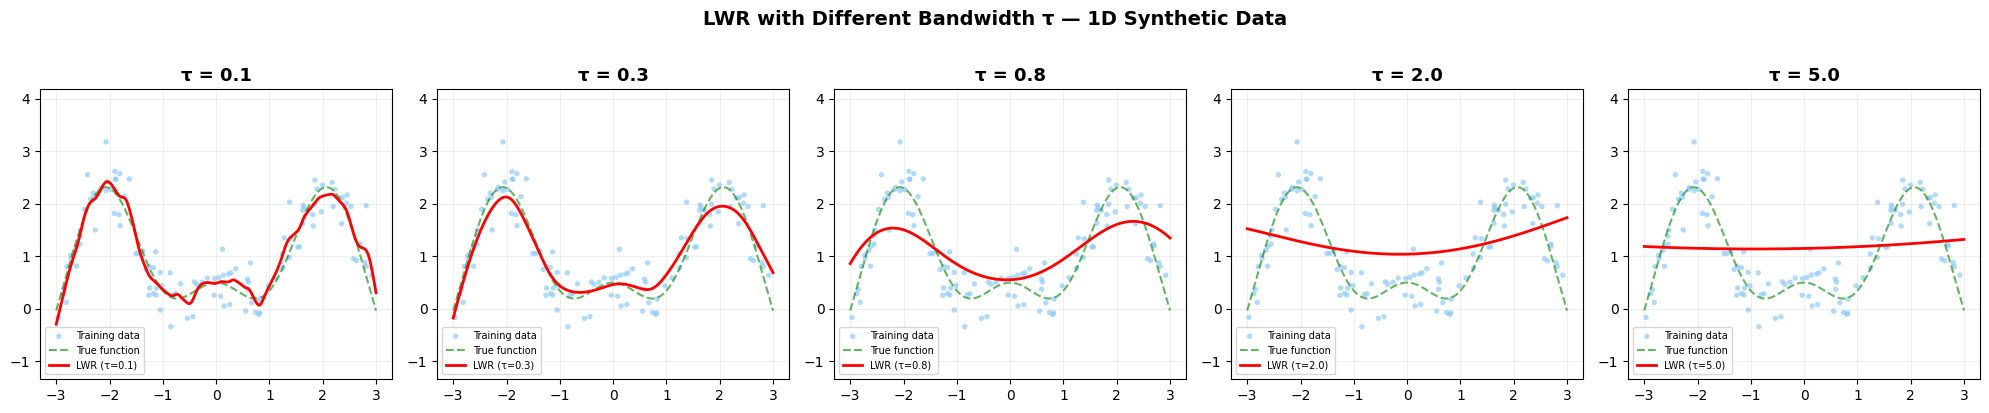


  Observations:
  ● τ = 0.1 : Extremely wiggly — overfits noise.
  ● τ = 0.3 : Captures local trends well, slight overfitting.
  ● τ = 0.8 : Good balance — tracks the true function smoothly.
  ● τ = 2.0 : Starts to oversmooth, misses some bends.
  ● τ = 5.0 : Nearly a straight line — approaches global LR, underfits.



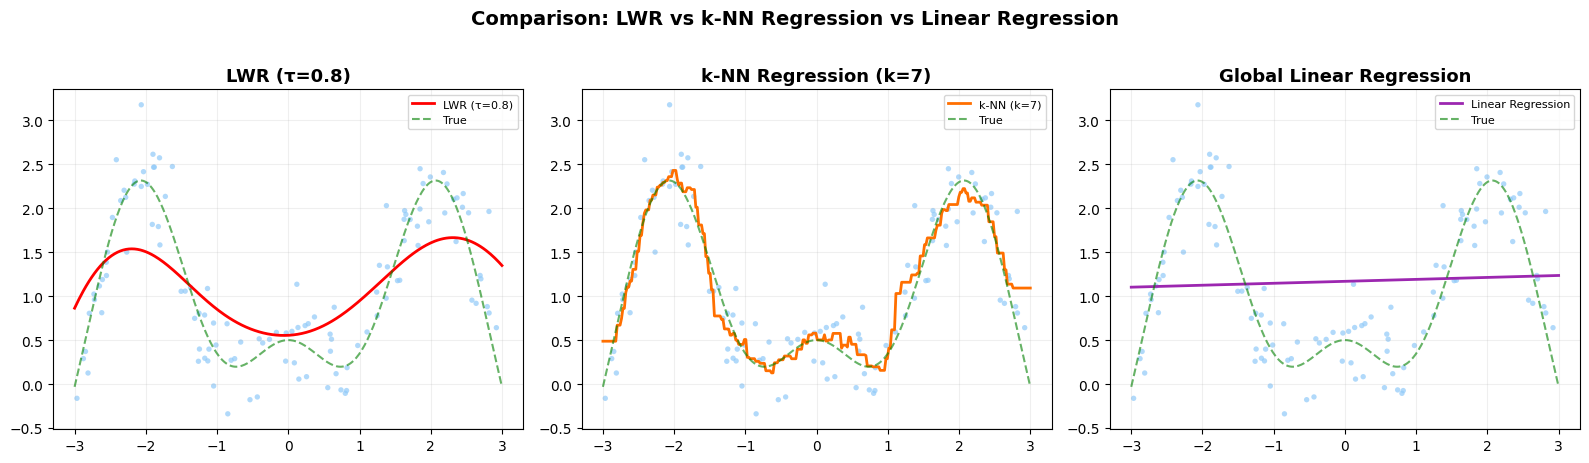


  Key take-aways:
  ● LWR gives the SMOOTHEST, best-fitting curve for non-linear data.
  ● k-NN regression produces a STEP-LIKE (piecewise constant) fit.
  ● Global linear regression CANNOT capture non-linearity at all.



In [10]:
weighted_regression.demo_1d_synthetic()

## 9. Application — Demo 2: Iris (Regression)

We adapt the Iris dataset for regression: **predict petal width** from sepal length, sepal width, and petal length.  
This lets us compare LWR, k-NN regression, and global LR on a real multi-feature dataset.


  DEMO 2 — IRIS (Predict Petal Width)
  Features : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)']
  Target   : petal width (cm)
  Samples  : 150
    τ = 0.1    MSE = 0.1694   R² = 0.7358
    τ = 0.3    MSE = 0.0475   R² = 0.9260
    τ = 0.5    MSE = 0.0425   R² = 0.9337
    τ = 1.0    MSE = 0.0388   R² = 0.9396
    τ = 2.0    MSE = 0.0400   R² = 0.9377
    τ = 5.0    MSE = 0.0405   R² = 0.9369

  k-NN Regression:
    k = 3      MSE = 0.0569   R² = 0.9113
    k = 5      MSE = 0.0498   R² = 0.9223
    k = 7      MSE = 0.0462   R² = 0.9280
    k = 9      MSE = 0.0486   R² = 0.9242
    k = 11     MSE = 0.0510   R² = 0.9204

  Global LR   MSE = 0.0405   R² = 0.9369


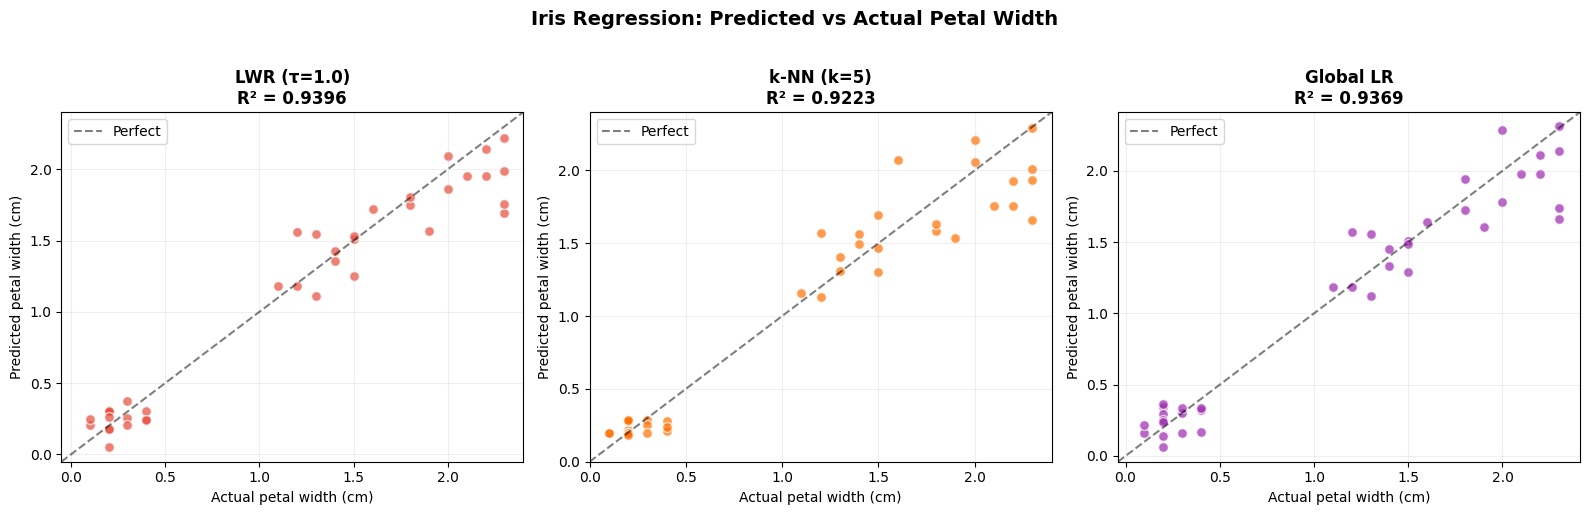

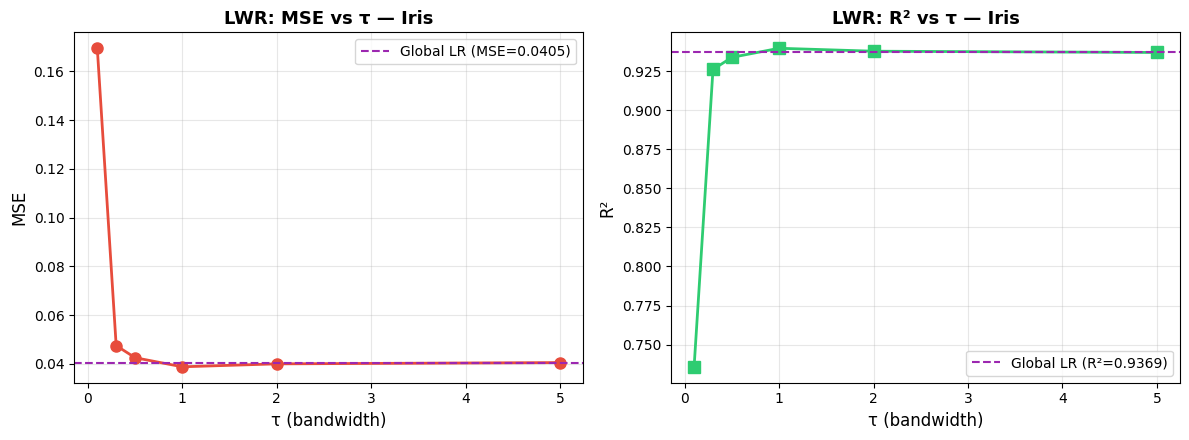

In [11]:
weighted_regression.demo_iris_regression()

## 10. Application — Demo 3: Wine (Regression)

We predict **alcohol content** from the remaining 12 features of the Wine dataset.  
This tests LWR in a higher-dimensional space (12 features).


  DEMO 3 — WINE (Predict Alcohol Content)
  Features : ['malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline'] (12 features)
  Target   : alcohol
  Samples  : 178

  LWR Results:
    τ = 0.3    MSE = 42.6388   R² = -74.7940
    τ = 0.5    MSE = 7.9412   R² = -13.1162
    τ = 1.0    MSE = 0.3352   R² = 0.4041
    τ = 2.0    MSE = 0.1900   R² = 0.6623
    τ = 3.0    MSE = 0.1843   R² = 0.6724
    τ = 5.0    MSE = 0.1922   R² = 0.6584

  k-NN Regression:
    k = 3      MSE = 0.2303   R² = 0.5907
    k = 5      MSE = 0.1841   R² = 0.6728
    k = 7      MSE = 0.1893   R² = 0.6636
    k = 9      MSE = 0.2052   R² = 0.6353

  Global LR   MSE = 0.1963   R² = 0.6510


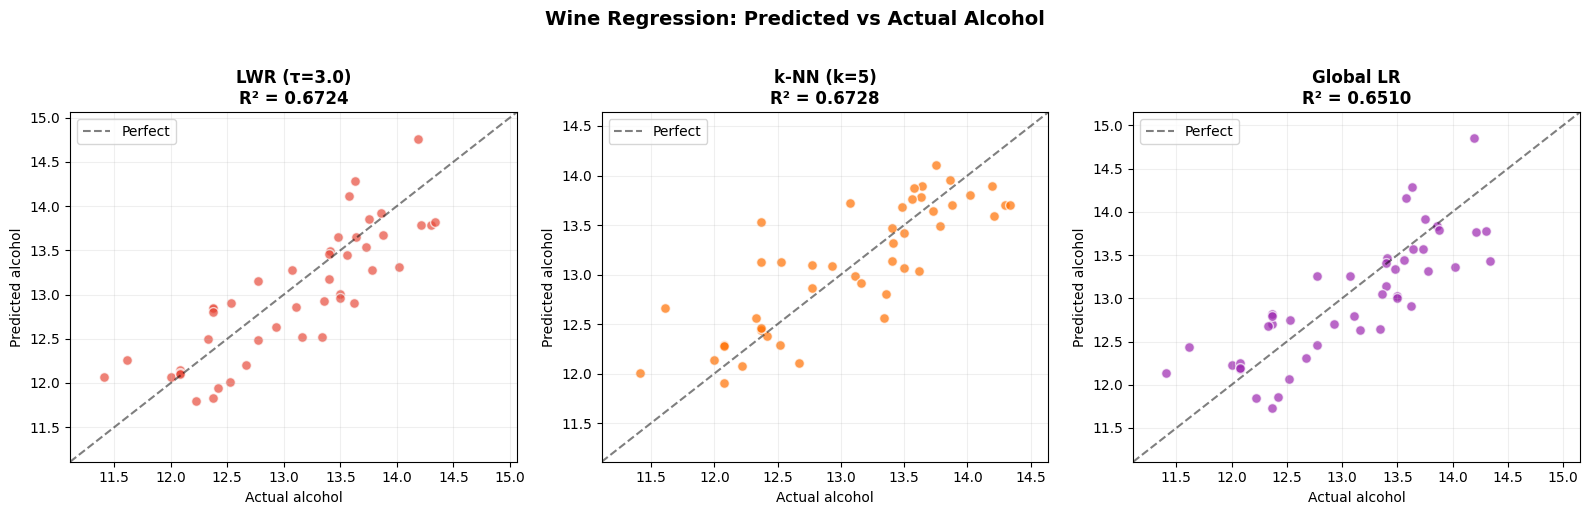

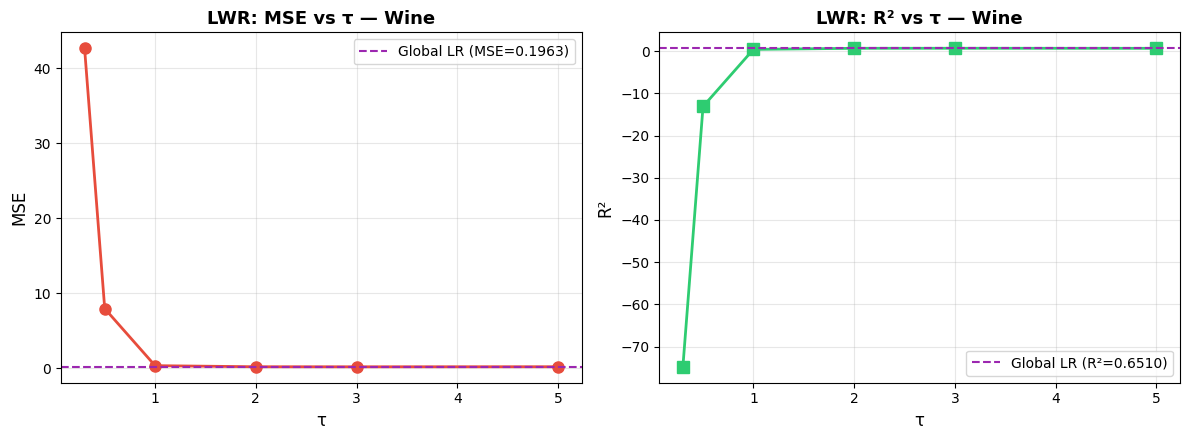

In [12]:
weighted_regression.demo_wine_regression()

---
## Summary & Key Takeaways

| | k-NN | LWR |
|---|------|-----|
| **Type** | Classification & Regression | Regression |
| **Hyper-parameter** | k (number of neighbours) | τ (bandwidth) |
| **Local model** | None (majority vote / mean) | Weighted linear fit |
| **Bias-variance** | k controls trade-off | τ controls trade-off |
| **Fit smoothness** | Piecewise constant | Piecewise linear (smooth) |
| **Best for** | Classification, simple regression | Smooth non-linear regression |
| **Key weakness** | Curse of dimensionality | Computational cost O(n·d²)/query |

**Both are instance-based (lazy) learners:**
- No training phase — all computation at query time.
- Must store the full training set in memory.
- Feature scaling is critical for both.
- Performance degrades in very high dimensions.

---
